In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
import pandas as pd

nav_df = pd.read_csv("../data/processed/clean_nav_history.csv")
trans_df = pd.read_csv("../data/processed/clean_investor_transactions.csv")
aum_df = pd.read_csv("../data/processed/clean_scheme_aum.csv")
perf_df = pd.read_csv("../data/processed/clean_scheme_performance.csv")

print(nav_df.shape)
print(trans_df.shape)
print(aum_df.shape)
print(perf_df.shape)

(364, 3)
(10, 7)
(4, 2)
(4, 5)


In [5]:
print(nav_df.shape)
print(nav_df.columns.tolist())

(364, 3)
['amfi_code', 'date', 'nav']


In [6]:
print(aum_df.columns.tolist())
print(aum_df.head())

['amfi_code', 'aum_crores']
   amfi_code  aum_crores
0     119551       35000
1     120503       42000
2     118632       28000
3     125497       51000


In [7]:
print(trans_df.columns.tolist())
print(trans_df.head())

['transaction_id', 'amfi_code', 'transaction_type', 'amount', 'date', 'state', 'kyc_status']
   transaction_id  amfi_code transaction_type  amount        date  \
0               1     119551              SIP    5000  2024-01-05   
1               2     120503          Lumpsum   10000  2024-01-06   
2               3     118632       Redemption    2500  2024-01-07   
3               4     125497              SIP    4000  2024-01-08   
4               5     119551          Lumpsum   12000  2024-01-09   

            state kyc_status  
0       Telangana   VERIFIED  
1  Andhra Pradesh   VERIFIED  
2       Karnataka    PENDING  
3     Maharashtra   VERIFIED  
4       Telangana     FAILED  


In [8]:
print(perf_df.columns.tolist())
print(perf_df.head())

['amfi_code', 'fund_name', 'returns', 'expense_ratio', 'expense_anomaly_flag']
   amfi_code            fund_name  returns  expense_ratio  \
0     119551         SBI Bluechip     15.4            1.2   
1     120503       ICICI Bluechip     22.1            0.8   
2     118632     Nippon Large Cap     18.2            1.9   
3     125497  HDFC Top 100 Direct     12.8            2.8   

   expense_anomaly_flag  
0                     0  
1                     0  
2                     0  
3                     1  


In [9]:
import plotly.express as px

fig = px.bar(
    perf_df,
    x='fund_name',
    y='returns',
    color='returns',
    title='Fund Returns Comparison'
)

fig.show()

In [10]:
fig = px.bar(
    perf_df,
    x='fund_name',
    y='expense_ratio',
    color='expense_ratio',
    title='Expense Ratio by Fund'
)

fig.show()

In [11]:
fig = px.scatter(
    perf_df,
    x='expense_ratio',
    y='returns',
    text='fund_name',
    title='Return vs Expense Ratio'
)

fig.show()

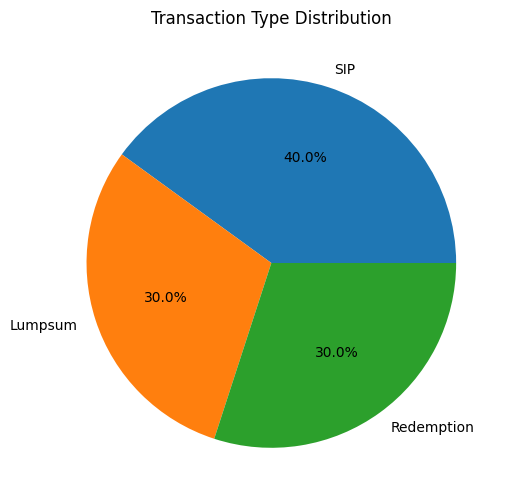

In [12]:
trans_df['transaction_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    title='Transaction Type Distribution'
)

plt.ylabel('')
plt.show()

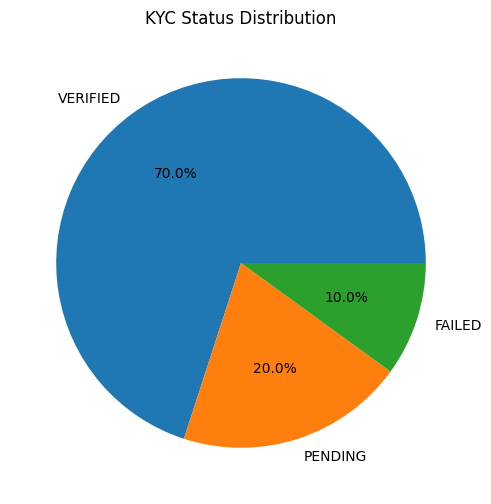

In [13]:
trans_df['kyc_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    title='KYC Status Distribution'
)

plt.ylabel('')
plt.show()

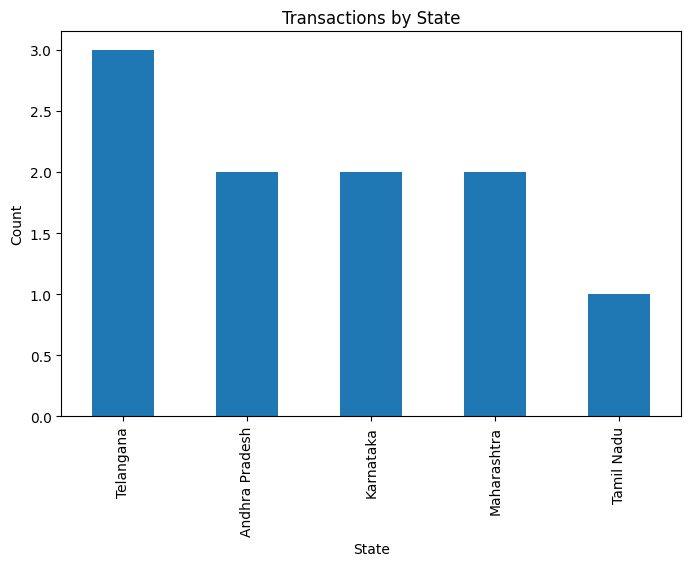

In [14]:
trans_df['state'].value_counts().plot(
    kind='bar',
    figsize=(8,5),
    title='Transactions by State'
)

plt.xlabel('State')
plt.ylabel('Count')
plt.show()


In [15]:
aum_merge = perf_df.merge(aum_df, on='amfi_code')

fig = px.bar(
    aum_merge,
    x='fund_name',
    y='aum_crores',
    color='aum_crores',
    title='AUM by Fund'
)

fig.show()

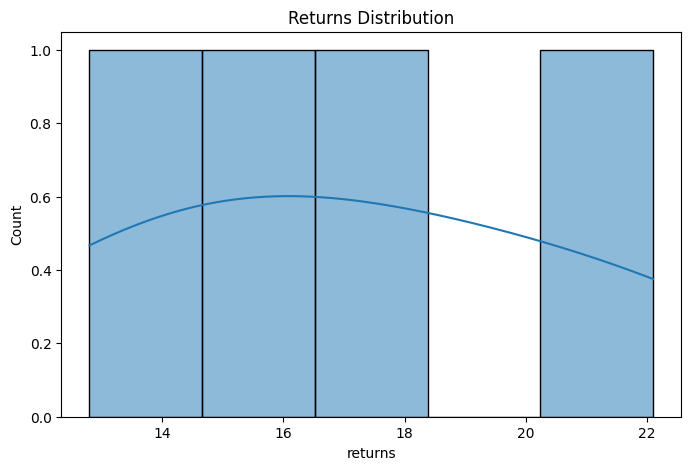

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    perf_df['returns'],
    bins=5,
    kde=True
)

plt.title("Returns Distribution")
plt.show()

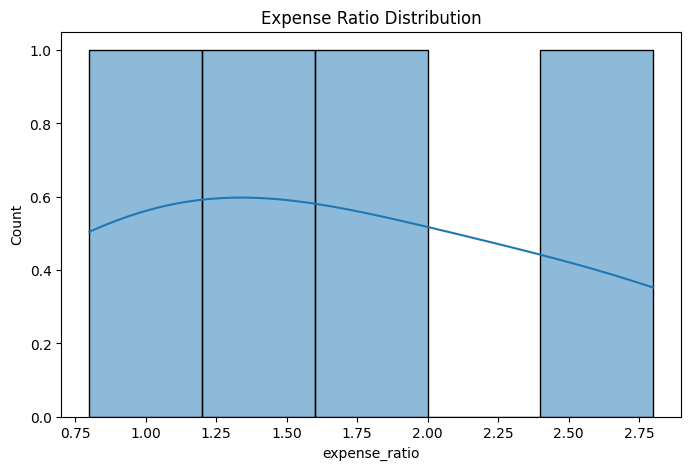

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    perf_df['expense_ratio'],
    bins=5,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.show()

In [18]:
top_funds = perf_df.sort_values(
    by='returns',
    ascending=False
)

fig = px.bar(
    top_funds,
    x='fund_name',
    y='returns',
    title='Top Performing Funds'
)

fig.show()

In [20]:
top_funds = perf_df.sort_values(
    by='returns',
    ascending=False
)

fig = px.bar(
    top_funds,
    x='fund_name',
    y='returns',
    title='Top Performing Funds'
)

fig.show()